# Equity Volatility Forecasting & Implied-Realized Spread Analysis

This project examines whether information from equity and volatility markets can improve forecasts of future S&P 500 realized volatility and help identify periods when implied volatility is high relative to what is later realized.

The first section builds a current SPY option pricing framework to recover implied volatility, calculate Greeks, and illustrate dynamic delta hedging. The historical sections then compare VIX with subsequent S&P 500 realized volatility, build out-of-sample forecasting models, study performance across volatility regimes, and construct an implied-realized volatility spread signal.

**Main Questions**

1. How does implied volatility vary across strikes and maturities in current SPY options?
2. How informative is VIX about volatility realized over the next 21 trading days?
3. Can recent market information improve realized volatility forecasts relative to VIX alone?
4. Can those forecasts identify periods when the implied-realized volatility spread is unusually large?

In [28]:
!pip install yfinance statsmodels scikit-learn -q

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm

from scipy.stats import norm
from scipy.optimize import brentq

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

## 1. Option Pricing Framework

### Black-Scholes and Greeks

In [29]:
def bs_call_price(S, K, T, r, sigma, q=0):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_call_delta(S, K, T, r, sigma, q=0):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

    return np.exp(-q * T) * norm.cdf(d1)

def bs_gamma(S, K, T, r, sigma, q=0):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

    return np.exp(-q * T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma, q=0):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)

def objective(sigma, price, S, K, T, r, q):
    # To be used to minimize difference between market price and Black Scholes price
    return bs_call_price(S, K, T, r, sigma, q) - price

def implied_vol_call(price, S, K, T, r, q=0):
    # Check no-arbitrage bounds
    lower = max(S * np.exp(-q * T) - K * np.exp(-r * T), 0)
    upper = S * np.exp(-q * T)

    if price <= lower or price >= upper:
        return np.nan

    try:
        return brentq(objective, 1e-6, 5.0, args=(price, S, K, T, r, q))
    except ValueError:
        return np.nan

### Risk-Free Rate Inputs

Black-Scholes discounting would ideally use the relevant zero-coupon curve. Treasury constant maturity yields are used here as a short-maturity proxy.

In [30]:
def get_fred_rate(series):
    data = pd.read_csv(f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}")
    return pd.to_numeric(data[series], errors="coerce").dropna().iloc[-1] / 100

# Get rates at 1 month, 3 month, and 6 month maturities
r_1m = get_fred_rate("DGS1MO")
r_3m = get_fred_rate("DGS3MO")
r_6m = get_fred_rate("DGS6MO")

rate_times = np.array([1 / 12, 3 / 12, 6 / 12])
rates = np.array([r_1m, r_3m, r_6m])

def get_rate(T):
    return np.interp(T, rate_times, rates)

### Current SPY Option Data and Implied Volatility

SPY options are American-style, while the Black-Scholes and put-call parity formulas used here are European. Put-call parity is therefore used as an approximation. The forward is estimated from the median of five near-ATM call-put pairs to reduce sensitivity to individual quotes.

In [31]:
ticker = yf.Ticker("SPY")

spot = ticker.history(period="1d")["Close"].iloc[-1]
expirations = ticker.options
today = pd.Timestamp.today().normalize()

# Process each expiration separately, then concatenate
rows = []

for expiry in expirations:
    expiry_date = pd.Timestamp(expiry)
    T = (expiry_date - today).days / 365

    # Only retain options between 7 and 180 days; very short-dated options can be very noisy, very long-dated options aren't necessary to analyze
    if T < 7 / 365 or T > 180 / 365:
        continue

    r = get_rate(T)

    chain = ticker.option_chain(expiry)
    calls = chain.calls.copy()
    puts = chain.puts.copy()

    # Use mid price as proxy for option price
    calls["mid"] = (calls["bid"] + calls["ask"]) / 2
    puts["mid"] = (puts["bid"] + puts["ask"]) / 2

    # Match calls and puts at identical strikes
    parity = calls[["strike", "mid"]].rename(columns={"mid": "call_mid"}).merge(puts[["strike", "mid"]].rename(columns={"mid": "put_mid"}), on="strike")
    parity = parity[(parity["call_mid"] > 0) & (parity["put_mid"] > 0)].copy()

    if len(parity) == 0:
        continue

    # Choose 5 strikes closest to current SPY price (i.e., near-ATM options); these generally have better liquidity + tighter spreads, meaning prices should give a more stable estimate of forward
    parity["distance"] = abs(parity["strike"] - spot)
    parity = parity.nsmallest(5, "distance")

    # Apply put-call parity to find forward price
    parity["forward"] = parity["strike"] + np.exp(r * T) * (parity["call_mid"] - parity["put_mid"])
    F = parity["forward"].median()

    if F <= 0:
        continue

    q = r - np.log(F / spot) / T

    calls["expiry"] = expiry
    calls["T"] = T
    calls["r"] = r
    calls["q"] = q
    calls["forward"] = F

    rows.append(calls)

options = pd.concat(rows, ignore_index=True)

options = options[(options["bid"] > 0) & (options["ask"] >= options["bid"])].copy()

# Exclude deep ITM / OTM options
options = options[(options["strike"] > 0.85 * spot) & (options["strike"] < 1.15 * spot)].copy()

options["iv_calc"] = options.apply(lambda row: implied_vol_call(row["mid"], spot, row["strike"], row["T"], row["r"], row["q"]), axis=1)

options = options[options["iv_calc"].between(0.01, 2)].copy()
options["spread_pct"] = (options["ask"] - options["bid"]) / options["mid"]
options = options[options["spread_pct"] <= 0.20].copy()

# Log-moneyness is a measure of how far the strike is from the forward price on a log scale
# Log-moneyness = 0 -> ATM
# Log-moneyness < 0 -> strike below forward
# Log-moneyness > 0 -> strike above forward
options["log_moneyness"] = np.log(options["strike"] / options["forward"])

options[["expiry", "strike", "mid", "T", "r", "q", "forward", "iv_calc"]].head()

,expiry,strike,mid,T,r,q,forward,iv_calc
19,2026-09-11,655.0,115.115,0.019178,0.0383,0.045066,770.090066,0.477035
20,2026-09-11,660.0,110.110,0.019178,0.0383,0.045066,770.090066,0.452585
21,2026-09-11,665.0,105.130,0.019178,0.0383,0.045066,770.090066,0.440636
22,2026-09-11,670.0,100.135,0.019178,0.0383,0.045066,770.090066,0.421202
23,2026-09-11,675.0,95.145,0.019178,0.0383,0.045066,770.090066,0.403827


### 30-Day Volatility Smile

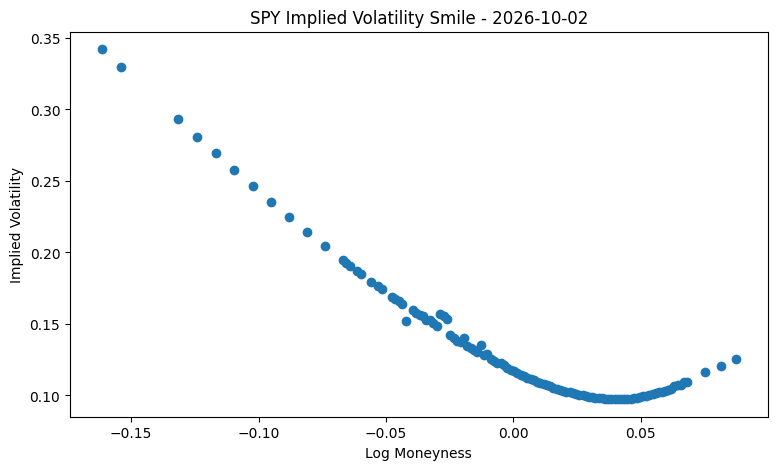

In [32]:
expiry_times = options.groupby("expiry")["T"].first()
expiry = (expiry_times - 30 / 365).abs().idxmin()

subset = options[options["expiry"] == expiry].sort_values("log_moneyness")

plt.figure(figsize=(9, 5))
plt.scatter(subset["log_moneyness"], subset["iv_calc"])
plt.xlabel("Log Moneyness")
plt.ylabel("Implied Volatility")
plt.title(f"SPY Implied Volatility Smile - {expiry}")
plt.show()

### Volatility Smile Across Expirations

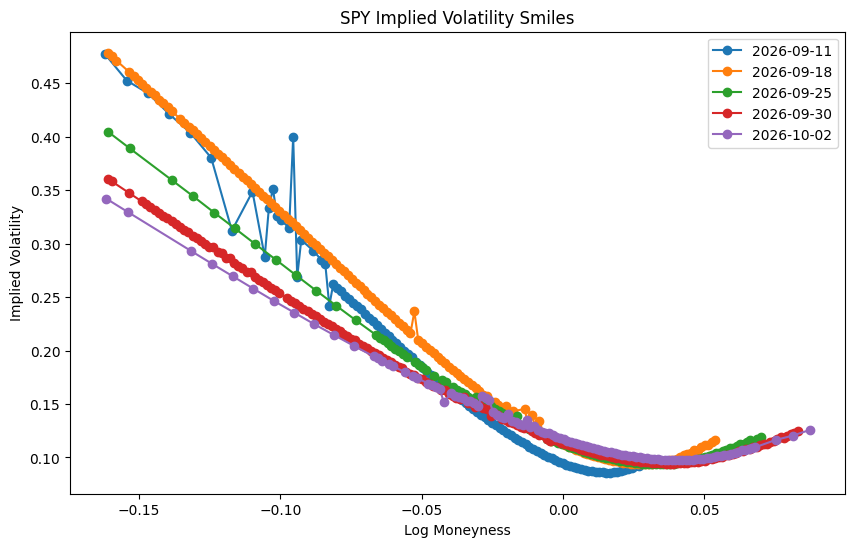

In [33]:
plt.figure(figsize=(10, 6))

for expiry in options["expiry"].unique()[:5]:
    subset = options[options["expiry"] == expiry].sort_values("log_moneyness")
    plt.plot(subset["log_moneyness"], subset["iv_calc"], marker="o", label=expiry)

plt.xlabel("Log Moneyness")
plt.ylabel("Implied Volatility")
plt.title("SPY Implied Volatility Smiles")
plt.legend()
plt.show()

### Greeks for a Near-ATM Option

In [34]:
expiry_times = options.groupby("expiry")["T"].first()
greek_expiry = (expiry_times - 30 / 365).abs().idxmin()

greek_subset = options[options["expiry"] == greek_expiry].copy()

# Choose strike closest to current SPY price
greek_option = greek_subset.iloc[(greek_subset["strike"] - spot).abs().argsort()[:1]].iloc[0]

K = greek_option["strike"]
T = greek_option["T"]
r = greek_option["r"]
q = greek_option["q"]
sigma = greek_option["iv_calc"]

delta = bs_call_delta(spot, K, T, r, sigma, q)
gamma = bs_gamma(spot, K, T, r, sigma, q)
vega = bs_vega(spot, K, T, r, sigma, q)

print("Expiry:", greek_expiry)
print("Strike:", K)
print("Implied vol:", round(sigma, 4))
print("Delta:", round(delta, 4))
print("Gamma:", round(gamma, 6))
print("Vega:", round(vega, 4))
print("Shares to short for a delta-neutral hedge:", round(100 * delta, 4))

Expiry: 2026-10-02
Strike: 770.0
Implied vol: 0.1168
Delta: 0.5019
Gamma: 0.015956
Vega: 84.8087
Shares to short for a delta-neutral hedge: 50.1926


### Illustrative Delta Hedging

The following simulation shows how the delta hedge changes as the underlying price and time to expiration change. It uses one simulated GBM path with constant implied volatility.

In [35]:
np.random.seed(42)

# Ensure number of steps is between 5 and 21
n_steps = min(21, max(5, int(round(T * 252))))
dt = T / n_steps

S_path = [spot]
remaining_T = [T]
deltas = [bs_call_delta(spot, K, T, r, sigma, q)]

for i in range(1, n_steps + 1):
    z = np.random.normal()

    # Risk-neutral simulation
    S_new = S_path[-1] * np.exp((r - q - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
    tau = max(T - i * dt, 1e-6)

    S_path.append(S_new)
    remaining_T.append(tau)
    deltas.append(bs_call_delta(S_new, K, tau, r, sigma, q))

hedge = pd.DataFrame({"step": range(n_steps + 1), "SPY": S_path, "time_to_expiry": remaining_T, "delta": deltas})

hedge["shares_held"] = -hedge["delta"] * 100
hedge.head()

,step,SPY,time_to_expiry,delta,shares_held
0,0,770.190002,0.076712,0.501926,-50.192613
1,1,772.994026,0.072675,0.547848,-54.784799
2,2,772.160629,0.068637,0.535406,-53.540610
3,3,775.840692,0.064600,0.599268,-59.926764
4,4,784.619263,0.060562,0.741970,-74.196960


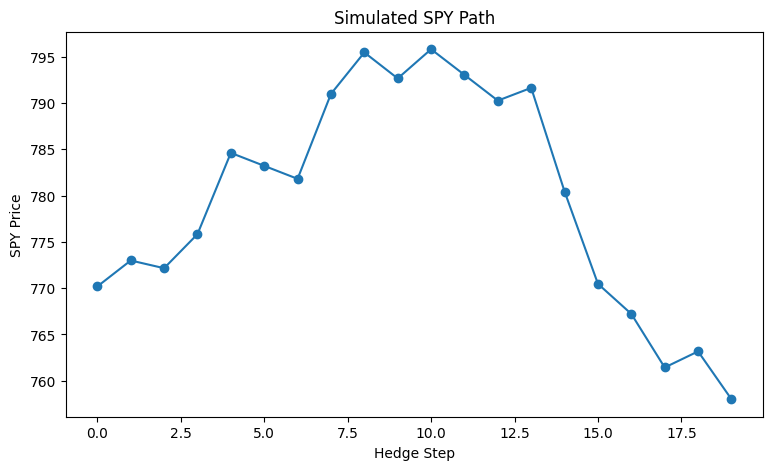

In [36]:
plt.figure(figsize=(9, 5))
plt.plot(hedge["step"], hedge["SPY"], marker="o")
plt.xlabel("Hedge Step")
plt.ylabel("SPY Price")
plt.title("Simulated SPY Path")
plt.show()

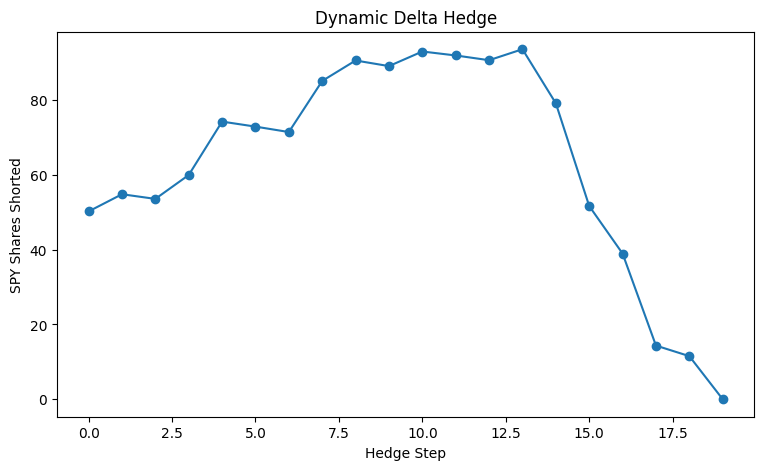

In [37]:
plt.figure(figsize=(9, 5))
plt.plot(hedge["step"], -hedge["shares_held"], marker="o")
plt.xlabel("Hedge Step")
plt.ylabel("SPY Shares Shorted")
plt.title("Dynamic Delta Hedge")
plt.show()

## 2. Historical Implied vs. Realized Volatility

VIX is derived from SPX option prices, so the historical comparison uses the S&P 500 cash index (`^GSPC`) for realized volatility. A 21 trading day horizon is used as an approximate one month period.

### Historical Data

In [38]:
start_date = "2010-01-01"
end_date = "2026-09-05"
horizon = 21

spx = yf.download("^GSPC", start=start_date, end=end_date, auto_adjust=False, progress=False)["Close"]

vix = yf.download("^VIX", start=start_date, end=end_date, auto_adjust=False, progress=False)["Close"]

spx = spx.iloc[:, 0]
vix = vix.iloc[:, 0]

data = pd.concat([spx.rename("SPX"), vix.rename("VIX")], axis=1).dropna()

data["return"] = np.log(data["SPX"] / data["SPX"].shift(1))

data["implied_vol"] = data["VIX"] / 100

### Future 21-Day Realized Volatility

In [39]:
# For each date, calculate the SPX volatility that actually occurs over the next 21 days, then compare with VIX on that date
future_realized = []

for i in range(len(data)):
    if i + horizon < len(data):
        returns = data["return"].iloc[i + 1:i + horizon + 1]
        realized_vol = np.sqrt(252 / horizon * np.sum(returns**2))
        future_realized.append(realized_vol)
    else:
        future_realized.append(np.nan)

data["future_realized_vol"] = future_realized
data["vol_spread"] = data["implied_vol"] - data["future_realized_vol"]

analysis = data.dropna().copy()

### Summary Statistics

In [40]:
mean_implied = analysis["implied_vol"].mean()
mean_realized = analysis["future_realized_vol"].mean()
mean_spread = analysis["vol_spread"].mean()
median_spread = analysis["vol_spread"].median()
percent_above = (analysis["vol_spread"] > 0).mean()
correlation = analysis["implied_vol"].corr(analysis["future_realized_vol"])

print("Average VIX:", round(mean_implied, 4))
print("Average future realized vol:", round(mean_realized, 4))
print("Average spread:", round(mean_spread, 4))
print("Median spread:", round(median_spread, 4))
print("Percent VIX > future realized vol:", round(percent_above, 4))
print("Correlation:", round(correlation, 4))

Average VIX: 0.1843
Average future realized vol: 0.147
Average spread: 0.0373
Median spread: 0.046
Percent VIX > future realized vol: 0.8444
Correlation: 0.6041


### Mean Implied-Realized Spread Test

A regression with only a constant tests whether the average VIX minus future realized-volatility spread differs from zero. HAC standard errors with 21 lags account for heteroskedasticity and dependence created by overlapping 21 day forward windows.

In [41]:
mean_test = sm.OLS(analysis["vol_spread"], np.ones(len(analysis))).fit(cov_type="HAC", cov_kwds={"maxlags": 21})

print("Mean spread:", mean_test.params.iloc[0])
print("t-stat:", mean_test.tvalues.iloc[0])
print("p-value:", mean_test.pvalues.iloc[0])

Mean spread: 0.03732888883637949
t-stat: 8.697915271704844
p-value: 3.3803677738384965e-18


**Interpretation:** The average VIX minus future realized volatility spread is about 3.7 volatility points and is strongly statistically significant. This means VIX has historically tended to price more volatility than the S&P 500 actually realized over the following 21 trading days.

### Predictive Regression

This regression tests whether current VIX contains information about S&P 500 volatility realized over the next 21 trading days.

In [42]:
X = sm.add_constant(analysis["implied_vol"])
model = sm.OLS(analysis["future_realized_vol"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 21})

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     future_realized_vol   R-squared:                       0.365
Model:                             OLS   Adj. R-squared:                  0.365
Method:                  Least Squares   F-statistic:                     94.10
Date:                 Fri, 04 Sep 2026   Prob (F-statistic):           5.13e-22
Time:                         21:27:44   Log-Likelihood:                 5051.1
No. Observations:                 4172   AIC:                        -1.010e+04
Df Residuals:                     4170   BIC:                        -1.009e+04
Df Model:                            1                                         
Covariance Type:                   HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0016      0.013     -0

### Recent Implied vs. Realized Volatility

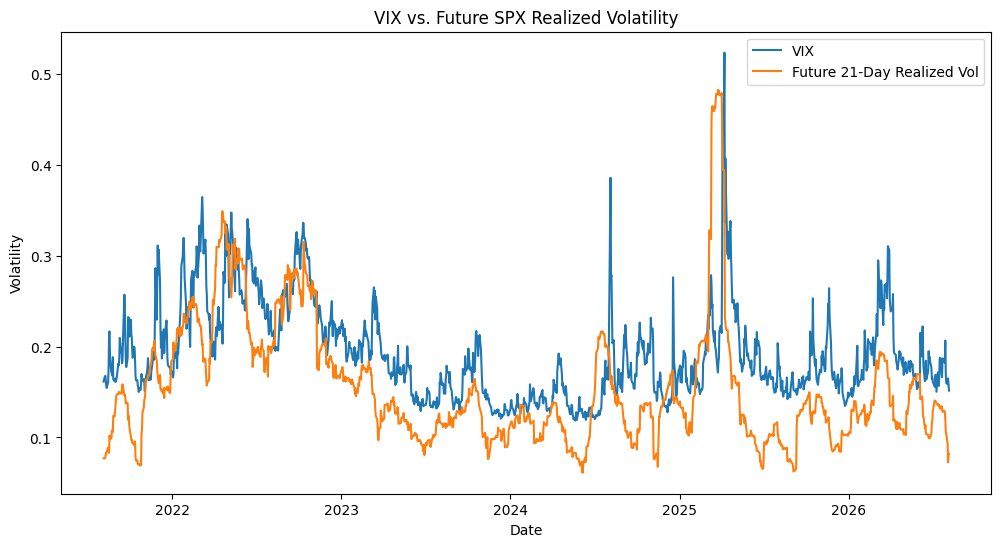

In [43]:
recent = analysis[analysis.index >= analysis.index.max() - pd.DateOffset(years=5)]

plt.figure(figsize=(12, 6))
plt.plot(recent.index, recent["implied_vol"], label="VIX")
plt.plot(recent.index, recent["future_realized_vol"], label="Future 21-Day Realized Vol")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("VIX vs. Future SPX Realized Volatility")
plt.legend()
plt.show()

### Implied vs. Realized Volatility Scatter

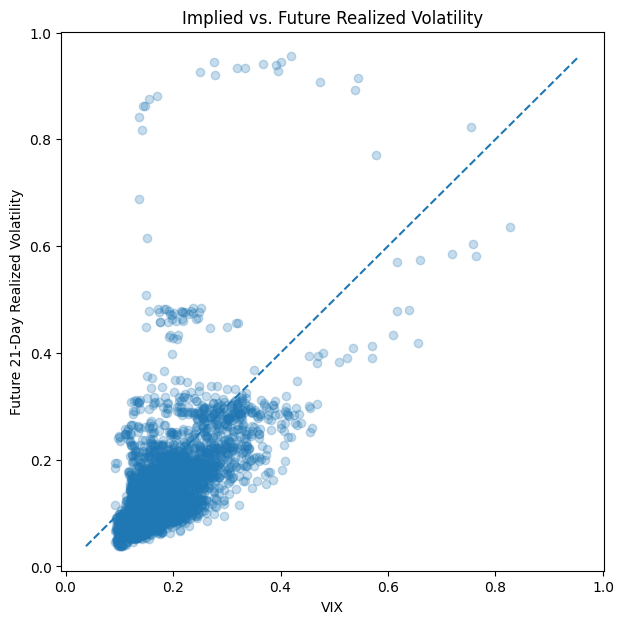

In [44]:
plt.figure(figsize=(7, 7))
plt.scatter(analysis["implied_vol"], analysis["future_realized_vol"], alpha=0.25)

low = min(analysis["implied_vol"].min(), analysis["future_realized_vol"].min())
high = max(analysis["implied_vol"].max(), analysis["future_realized_vol"].max())

plt.plot([low, high], [low, high], linestyle="--")
plt.xlabel("VIX")
plt.ylabel("Future 21-Day Realized Volatility")
plt.title("Implied vs. Future Realized Volatility")
plt.show()

### Implied-Realized Spread Distribution

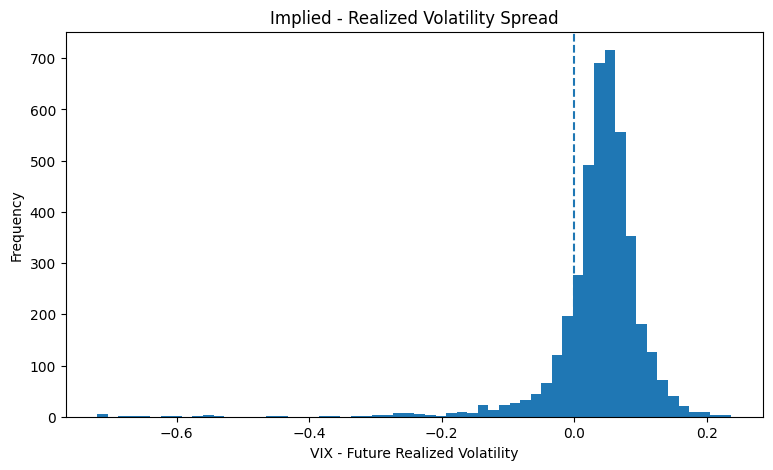

In [45]:
plt.figure(figsize=(9, 5))
plt.hist(analysis["vol_spread"], bins=60)
plt.axvline(0, linestyle="--")
plt.xlabel("VIX - Future Realized Volatility")
plt.ylabel("Frequency")
plt.title("Implied - Realized Volatility Spread")
plt.show()

### VIX Regimes

             implied_vol  future_realized_vol  vol_spread
vix_group                                                
Low             0.123379             0.102488    0.020891
Medium-Low      0.153420             0.124447    0.028973
Medium-High     0.185919             0.142217    0.043701
High            0.274686             0.218912    0.055773


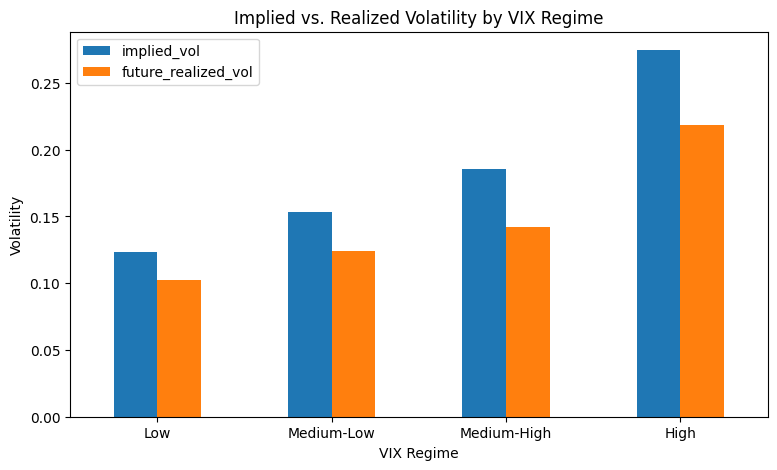

In [46]:
analysis["vix_group"] = pd.qcut(analysis["implied_vol"], 4, labels=["Low", "Medium-Low", "Medium-High", "High"])

regime_results = analysis.groupby("vix_group", observed=False)[["implied_vol", "future_realized_vol", "vol_spread"]].mean()

print(regime_results)

regime_results[["implied_vol", "future_realized_vol"]].plot(kind="bar", figsize=(9, 5))
plt.ylabel("Volatility")
plt.xlabel("VIX Regime")
plt.title("Implied vs. Realized Volatility by VIX Regime")
plt.xticks(rotation=0)
plt.show()

**Interpretation:** Implied volatility is higher than subsequent realized volatility in every VIX regime. The average spread also increases as the VIX regime rises, from about 2.1 volatility points in the Low regime to about 5.6 points in the High regime.

## 3. Realized Volatility Forecasting

The forecasting section uses only information available at each date to predict S&P 500 realized volatility over the next 21 trading days. The main benchmark is VIX itself. A second benchmark uses the most recent 21 day realized volatility.

### Feature Engineering

In [47]:
forecast = data.copy()

# Recent realized volatility over short, medium, and longer windows
for window in [5, 21, 63]:
    forecast[f"rv_{window}d"] = np.sqrt(252 / window * forecast["return"].pow(2).rolling(window).sum())

# Recent downside realized volatility
downside_squared_returns = np.minimum(forecast["return"], 0).pow(2)
forecast["downside_rv_21d"] = np.sqrt(252 / 21 * downside_squared_returns.rolling(21).sum())

# Recent SPX returns and drawdown
forecast["spx_return_5d"] = np.log(forecast["SPX"] / forecast["SPX"].shift(5))
forecast["spx_return_21d"] = np.log(forecast["SPX"] / forecast["SPX"].shift(21))
forecast["drawdown_21d"] = forecast["SPX"] / forecast["SPX"].rolling(21).max() - 1

# Changes and variation in implied volatility
forecast["vix_change_5d"] = forecast["implied_vol"] - forecast["implied_vol"].shift(5)
forecast["vix_vol_21d"] = forecast["implied_vol"].rolling(21).std()

features = ["implied_vol", "rv_5d", "rv_21d", "rv_63d", "downside_rv_21d", "spx_return_5d", "spx_return_21d", "drawdown_21d", "vix_change_5d", "vix_vol_21d"]

model_data = forecast[features + ["future_realized_vol", "vol_spread"]].dropna().copy()

model_data.head()

,implied_vol,rv_5d,rv_21d,rv_63d,downside_rv_21d,spx_return_5d,spx_return_21d,drawdown_21d,vix_change_5d,vix_vol_21d,future_realized_vol,vol_spread
Date,,,,,,,,,,,,
2010-04-06,0.1623,0.081100,0.072084,0.139936,0.029022,0.013730,0.043595,0.000000,-0.0136,0.006293,0.172722,-0.010422
2010-04-07,0.1662,0.091258,0.074917,0.140294,0.035479,0.007794,0.037877,-0.005877,-0.0051,0.006476,0.205903,-0.039703
2010-04-08,0.1648,0.091423,0.075589,0.140451,0.035479,0.014441,0.039534,-0.002522,-0.0111,0.006632,0.212404,-0.047604
2010-04-09,0.1614,0.088572,0.077470,0.140855,0.035479,0.013716,0.041682,0.000000,-0.0133,0.006438,0.258470,-0.097070
2010-04-12,0.1558,0.069708,0.076445,0.140782,0.035479,0.007584,0.039413,0.000000,-0.0144,0.007015,0.258667,-0.102867


### Walk-Forward Model Comparison

An expanding training window is used, with one calendar year held out at a time. The final 21 observations before each test year are excluded from training so that forward realized volatility labels do not overlap the test period. Ridge and Lasso tune their regularization parameters using time series cross-validation with the same 21 day gap.

In [48]:
test_years = [year for year in sorted(model_data.index.year.unique()) if year >= 2017]

prediction_frames = []

for year in test_years:
    test_positions = np.where(model_data.index.year == year)[0]

    first_test_position = test_positions[0]
    train_end = first_test_position - horizon

    if train_end < 500:
        continue

    train = model_data.iloc[:train_end].copy()
    test = model_data.iloc[test_positions].copy()

    X_train = train[features]
    y_train = train["future_realized_vol"]

    X_test = test[features]
    y_test = test["future_realized_vol"]

    inner_cv = TimeSeriesSplit(n_splits=5, gap=horizon)

    linear = Pipeline([("scale", StandardScaler()), ("model", LinearRegression())])

    ridge = GridSearchCV(Pipeline([("scale", StandardScaler()), ("model", Ridge())]), {"model__alpha": np.logspace(-4, 4, 25)}, cv=inner_cv, scoring="neg_mean_squared_error")

    lasso = GridSearchCV(Pipeline([("scale", StandardScaler()), ("model", Lasso(max_iter=20000))]), {"model__alpha": np.logspace(-5, 0, 25)}, cv=inner_cv, scoring="neg_mean_squared_error")

    random_forest = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=20, max_features=0.8, random_state=42, n_jobs=-1)

    models = {"Linear": linear, "Ridge": ridge, "Lasso": lasso, "Random Forest": random_forest}

    fold_predictions = pd.DataFrame(index=test.index)
    fold_predictions["actual"] = y_test

    # VIX is a benchmark that predicts future realized volatility using today's implied volatility
    fold_predictions["VIX"] = test["implied_vol"]

    # Recent RV is a benchmark that predicts future realized volatility using the most recent 21-day realized volatility
    fold_predictions["Recent RV"] = test["rv_21d"]

    for name, fitted_model in models.items():
        fitted_model.fit(X_train, y_train)
        fold_predictions[name] = fitted_model.predict(X_test)

    prediction_frames.append(fold_predictions)

predictions = pd.concat(prediction_frames).sort_index()

predictions.head()

,actual,VIX,Recent RV,Linear,Ridge,Lasso,Random Forest
Date,,,,,,,
2017-01-03,0.056204,0.1285,0.083514,0.111913,0.112202,0.107798,0.121633
2017-01-04,0.058283,0.1185,0.085811,0.106278,0.106346,0.101450,0.096956
2017-01-05,0.058682,0.1167,0.083464,0.100464,0.100712,0.098711,0.091705
2017-01-06,0.057413,0.1132,0.083517,0.097745,0.097932,0.096311,0.091640
2017-01-09,0.056128,0.1156,0.071236,0.097852,0.095678,0.097638,0.093683


### Out-of-Sample Forecast Results

In [49]:
prediction_columns = ["VIX", "Recent RV", "Linear", "Ridge", "Lasso", "Random Forest"]

metrics = []

vix_mse = mean_squared_error(predictions["actual"], predictions["VIX"])

for name in prediction_columns:
    mse = mean_squared_error(predictions["actual"], predictions[name])

    metrics.append({"Model": name, "RMSE": np.sqrt(mse), "MAE": mean_absolute_error(predictions["actual"], predictions[name]), "R2": r2_score(predictions["actual"], predictions[name]), "MSE Improvement vs VIX": 1 - mse / vix_mse})

metrics_df = pd.DataFrame(metrics).set_index("Model").sort_values("RMSE")

print(metrics_df.round(4))

                 RMSE     MAE      R2  MSE Improvement vs VIX
Model                                                        
Ridge          0.0837  0.0456  0.3487                  0.1589
Lasso          0.0839  0.0449  0.3464                  0.1559
Linear         0.0845  0.0464  0.3369                  0.1437
Random Forest  0.0903  0.0489  0.2427                  0.0219
VIX            0.0913  0.0637  0.2257                  0.0000
Recent RV      0.1033  0.0571  0.0100                 -0.2786


**Interpretation:** Ridge and Lasso provide the best OOS forecasts of future realized volatility. Ridge has the lowest RMSE, while Lasso has the lowest MAE. Both reduce mean squared forecast error by about 16% relative to using VIX alone. The standard linear model also performs well, improving on VIX by about 14%, while the Random Forest provides only a small improvement. Recent realized volatility alone performs substantially worse than VIX.

### Out-of-Sample Forecast Plot

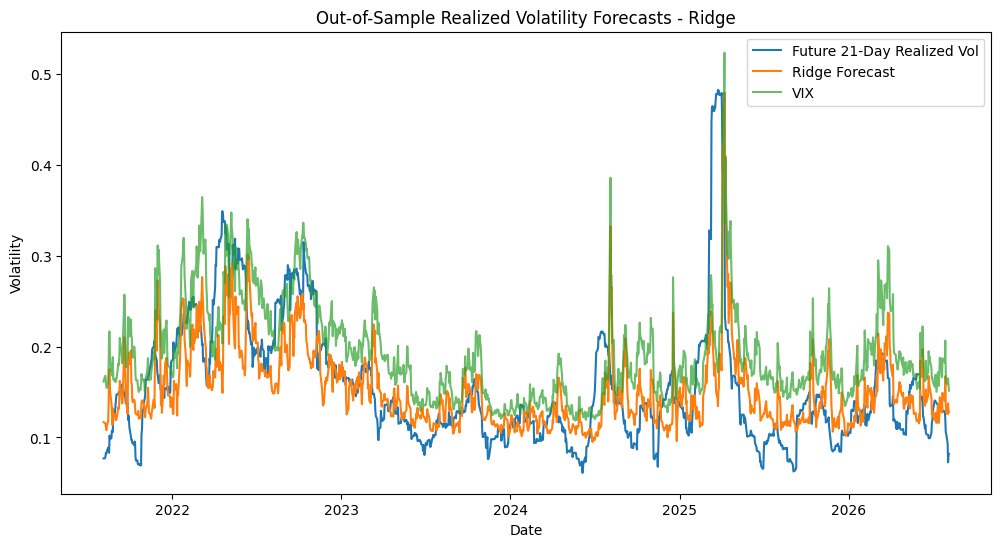

Best forecasting model: Ridge


In [50]:
candidate_models = ["Linear", "Ridge", "Lasso", "Random Forest"]
best_model = metrics_df.loc[candidate_models, "RMSE"].idxmin()

recent_predictions = predictions[predictions.index >= predictions.index.max() - pd.DateOffset(years=5)]

plt.figure(figsize=(12, 6))
plt.plot(recent_predictions.index, recent_predictions["actual"], label="Future 21-Day Realized Vol")
plt.plot(recent_predictions.index, recent_predictions[best_model], label=f"{best_model} Forecast")
plt.plot(recent_predictions.index, recent_predictions["VIX"], label="VIX", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title(f"Out-of-Sample Realized Volatility Forecasts - {best_model}")
plt.legend()
plt.show()

print("Best forecasting model:", best_model)

### Forecast Performance by VIX Regime

The out-of-sample sample is divided into four VIX quartiles. Within each regime, the best forecasting model is compared directly with VIX to show where the model adds the most value and where volatility is hardest to forecast.

In [51]:
regime_predictions = predictions.copy()

regime_predictions["vix_group"] = pd.qcut(regime_predictions["VIX"], 4, labels=["Low", "Medium-Low", "Medium-High", "High"])

regime_forecast_results = []

for group in ["Low", "Medium-Low", "Medium-High", "High"]:
    subset = regime_predictions[regime_predictions["vix_group"] == group]

    model_mse = mean_squared_error(subset["actual"], subset[best_model])
    vix_mse = mean_squared_error(subset["actual"], subset["VIX"])

    regime_forecast_results.append({"VIX Regime": group, "Observations": len(subset), "Model RMSE": np.sqrt(model_mse), "Model MAE": mean_absolute_error(subset["actual"], subset[best_model]), "VIX RMSE": np.sqrt(vix_mse), "VIX MAE": mean_absolute_error(subset["actual"], subset["VIX"]), "Improvement vs VIX": 1 - model_mse / vix_mse})

regime_forecast_results = pd.DataFrame(regime_forecast_results).set_index("VIX Regime")

print(regime_forecast_results.round(4))

             Observations  Model RMSE  Model MAE  VIX RMSE  VIX MAE  \
VIX Regime                                                            
Low                   604      0.0584     0.0340    0.0616   0.0443   
Medium-Low            604      0.0859     0.0394    0.0911   0.0575   
Medium-High           601      0.0609     0.0416    0.0741   0.0620   
High                  602      0.1165     0.0677    0.1257   0.0910   

             Improvement vs VIX  
VIX Regime                       
Low                      0.1020  
Medium-Low               0.1112  
Medium-High              0.3247  
High                     0.1403  


**Interpretation:** The model outperforms VIX in every volatility regime. The largest improvement occurs in the Medium-High regime, where mean squared error is reduced by about 32% relative to VIX. Forecast errors are highest in the High regime, showing that extreme volatility remains harder to predict, but the model still improves on VIX by about 14%.

### Feature Interpretation

Ridge alpha: 100.0
Lasso alpha: 0.001211527658628589
                  Ridge   Lasso
implied_vol      0.0273  0.0320
drawdown_21d    -0.0214 -0.0142
rv_5d            0.0110  0.0112
spx_return_21d   0.0096  0.0013
downside_rv_21d  0.0076  0.0000
vix_change_5d    0.0074  0.0047
spx_return_5d    0.0016 -0.0000
rv_63d          -0.0009  0.0000
rv_21d          -0.0006  0.0018
vix_vol_21d      0.0006  0.0001


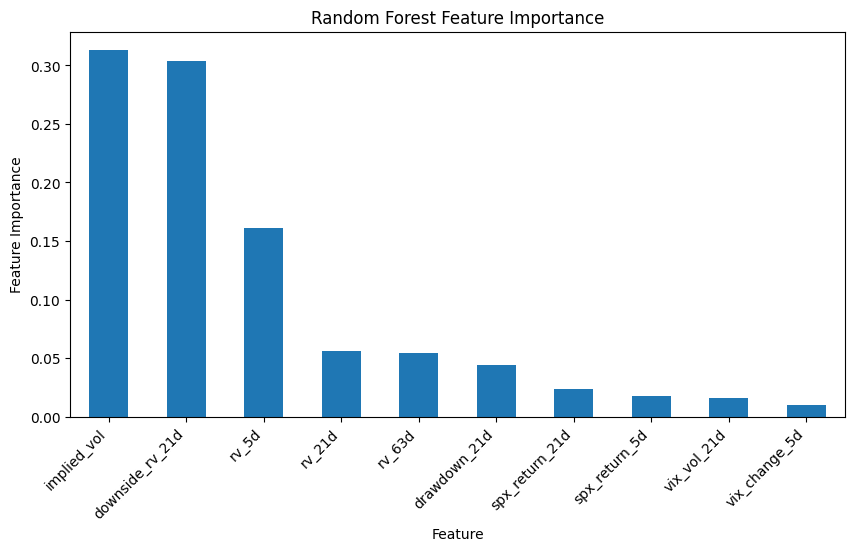

In [52]:
final_cv = TimeSeriesSplit(n_splits=5, gap=horizon)

ridge_final = GridSearchCV(Pipeline([("scale", StandardScaler()), ("model", Ridge())]), {"model__alpha": np.logspace(-4, 4, 25)}, cv=final_cv, scoring="neg_mean_squared_error")

lasso_final = GridSearchCV(Pipeline([("scale", StandardScaler()), ("model", Lasso(max_iter=20000))]), {"model__alpha": np.logspace(-5, 0, 25)}, cv=final_cv, scoring="neg_mean_squared_error")

random_forest_final = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=20, max_features=0.8, random_state=42, n_jobs=-1)

X_full = model_data[features]
y_full = model_data["future_realized_vol"]

ridge_final.fit(X_full, y_full)
lasso_final.fit(X_full, y_full)
random_forest_final.fit(X_full, y_full)

ridge_coefficients = ridge_final.best_estimator_.named_steps["model"].coef_
lasso_coefficients = lasso_final.best_estimator_.named_steps["model"].coef_

coefficient_results = pd.DataFrame({"Ridge": ridge_coefficients, "Lasso": lasso_coefficients}, index=features)

print("Ridge alpha:", ridge_final.best_params_["model__alpha"])
print("Lasso alpha:", lasso_final.best_params_["model__alpha"])
print(coefficient_results.round(4).sort_values("Ridge", key=abs, ascending=False))

feature_importance = pd.Series(random_forest_final.feature_importances_, index=features).sort_values(ascending=False)

feature_importance.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Feature Importance")
plt.xlabel("Feature")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

**Interpretation:** Current implied volatility is the strongest predictor of future realized volatility in the regularized linear models. Recent market drawdowns and short term realized volatility also contribute meaningfully. The negative drawdown coefficient means that larger market declines are associated with higher future volatility.

Lasso keeps only a relatively small set of predictors, which suggests that much of the useful forecasting information is concentrated in implied volatility, recent realized volatility, market drawdowns, and recent changes in VIX.

The Random Forest also identifies implied volatility as the most important feature, followed by downside realized volatility and 5 day realized volatility. This suggests that recent downside market stress may contain useful nonlinear information, although the Random Forest performed worse out of sample than Ridge and Lasso.

## 4. Implied-Realized Spread Signal

The best OOS realized volatility forecast is used to estimate the gap between volatility priced by the market and volatility expected by the model.

**Predicted Spread** = VIX - Predicted Future Realized Volatility

**Realized Spread** = VIX - Actual Future Realized Volatility

### Signal Regression

The regression tests whether larger predicted spreads are associated with larger spreads that subsequently occur.

In [57]:
signal = predictions[["actual", "VIX", best_model]].dropna().copy()

signal["predicted_spread"] = signal["VIX"] - signal[best_model]
signal["realized_spread"] = signal["VIX"] - signal["actual"]

signal_correlation = signal["predicted_spread"].corr(signal["realized_spread"])

X_signal = sm.add_constant(signal["predicted_spread"])
signal_test = sm.OLS(signal["realized_spread"], X_signal).fit(cov_type="HAC", cov_kwds={"maxlags": 21})

print("Correlation between predicted and realized spread:", round(signal_correlation, 4))
print(signal_test.summary())

Correlation between predicted and realized spread: 0.1463
                            OLS Regression Results                            
Dep. Variable:        realized_spread   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     4.318
Date:                Fri, 04 Sep 2026   Prob (F-statistic):             0.0378
Time:                        21:47:05   Log-Likelihood:                 2577.7
No. Observations:                2411   AIC:                            -5151.
Df Residuals:                    2409   BIC:                            -5140.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

**Interpretation:** The predicted spread has a positive relationship with the spread that is actually realized. A 1 volatility point increase in the predicted spread is associated with about a 0.55 point increase in the realized spread. The relationship is statistically significant at the 5% level, with a p-value of 0.038. However, the relationship is weak overall. The correlation is about 0.15 and the regression explains only about 2.1% of the variation in realized spreads. This means the predicted spread is informative, but not precise enough to forecast the exact size of the future spread on its own.

### Signal Quintiles

              predicted_spread  realized_spread
signal_group                                   
Lowest                  0.0158           0.0256
Low                     0.0267           0.0188
Middle                  0.0355           0.0272
High                    0.0455           0.0482
Highest                 0.0737           0.0595


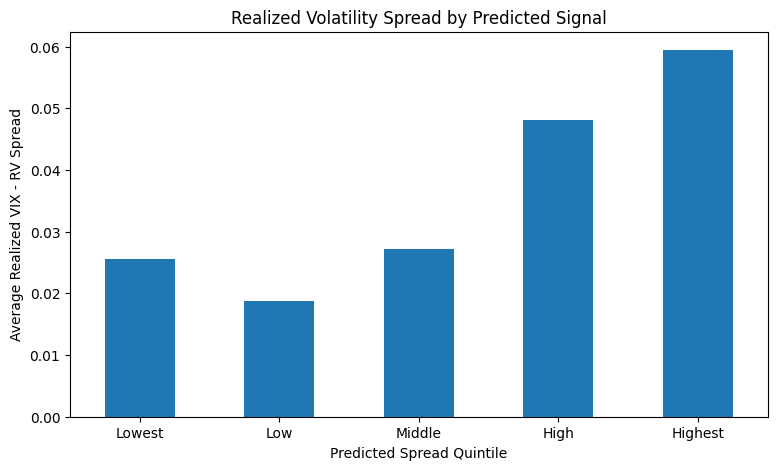

In [58]:
signal["signal_group"] = pd.qcut(signal["predicted_spread"], 5, labels=["Lowest", "Low", "Middle", "High", "Highest"])

signal_results = signal.groupby("signal_group", observed=False)[["predicted_spread", "realized_spread"]].mean()

print(signal_results.round(4))

signal_results["realized_spread"].plot(kind="bar", figsize=(9, 5))
plt.ylabel("Average Realized VIX - RV Spread")
plt.xlabel("Predicted Spread Quintile")
plt.title("Realized Volatility Spread by Predicted Signal")
plt.xticks(rotation=0)
plt.show()

**Interpretation:** The two highest predicted spread groups subsequently realized much larger VIX minus realized volatility spreads, at about 4.8 and 6.0 volatility points, compared with roughly 2 to 3 points in the lower groups. This suggests that the forecast is more useful for identifying periods when the implied-realized volatility gap is likely to be relatively large than for predicting its exact size. The relationship is not perfectly ordered across all five groups, but the separation in the top two quintiles is clear.